# Vizualize the difference of performance between AF-Cluster and AlphaConformer

In [1]:
import Pkg
Pkg.build()

┌ Warning: The active manifest file is an older format with no julia version entry. Dependencies may have been resolved with a different julia version.
└ @ nothing /store/EQUIPES/AMIG/MEMBERS/julie.daniel/AlphaConformers.jl/scripts/Manifest.toml:0
Precompiling project...
   7707.9 ms  ✓ Libgcrypt_jll
  12709.7 ms  ✓ Latexify
   4175.9 ms  ✓ XSLT_jll
   6702.4 ms  ✓ Latexify → SparseArraysExt
   7638.4 ms  ✓ UnitfulLatexify
  11681.6 ms  ✓ Qt6ShaderTools_jll
   6999.7 ms  ✓ Qt6Declarative_jll
   9910.8 ms  ✓ Qt6Wayland_jll
  49072.5 ms  ✓ Plots → UnitfulExt
  98708.2 ms  ✓ UnicodePlots
   8465.1 ms  ✓ UnicodePlots → UnitfulExt
  25118.4 ms  ✓ StatsPlots
  12 dependencies successfully precompiled in 185 seconds. 259 already precompiled.


In [ ]:
using DataFrames, StatsPlots, Colors, CSV

#get the csv 
df_path="Compare_output_AF.csv"
df=DataFrames.DataFrame(CSV.File(df_path,
        comment="#", missingstring=["", "None"])) 
first(df,5)

Row,Folder,File,rmsd_apo_holo,min_apo,mean_apo,var_apo,min_holo,mean_holo,var_holo
,String31,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1AKZ,1AKZ,1.5002,20.1309,22.051,1.58049,20.1068,22.0178,1.47728
2,1AKZ_AF_CLUSTER,1AKZ,1.5002,2.2767,13.732,58.4237,1.99558,13.6224,58.0012
3,1AKZ_AF_CLUSTER,1AKZ_U10,1.5002,0.971829,2.37733,0.526404,1.25064,2.31165,0.33791
4,1AKZ_AF_CLUSTER,1AKZ_U100,1.5002,0.49363,0.567974,0.00121571,1.23698,1.34127,0.00152258
5,1AKZ_AF_CLUSTER_template,1AKZ,1.5002,1.79782,13.5213,51.4714,1.77821,13.3829,50.2268


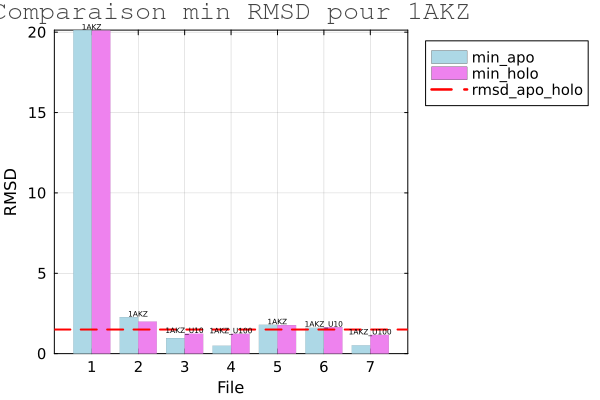

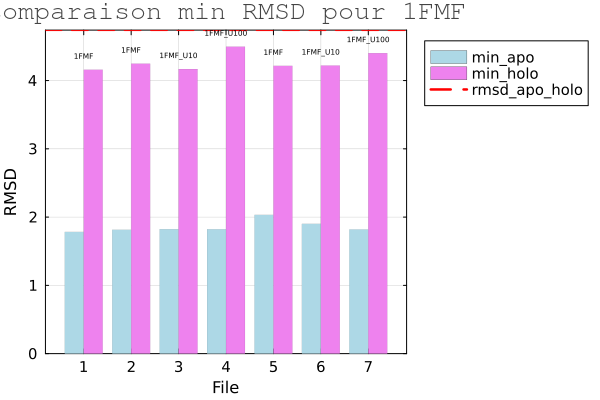

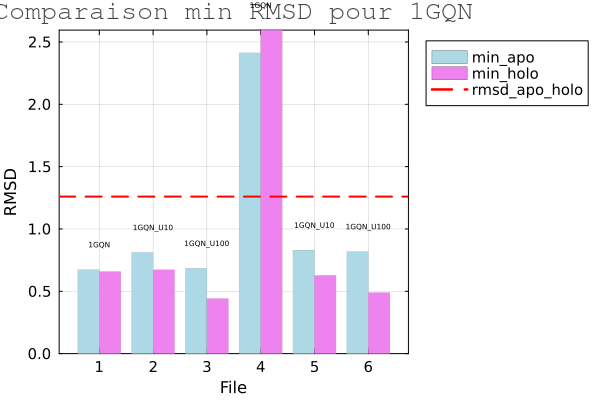

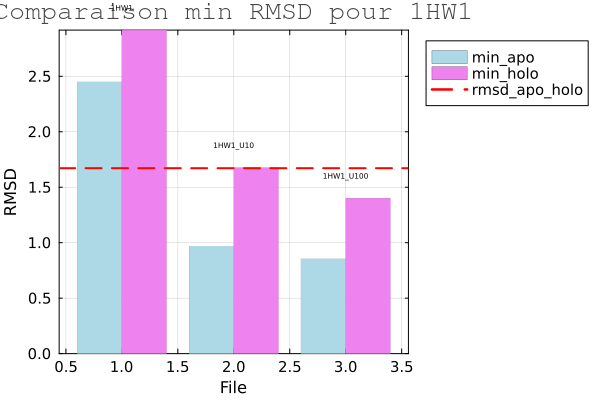

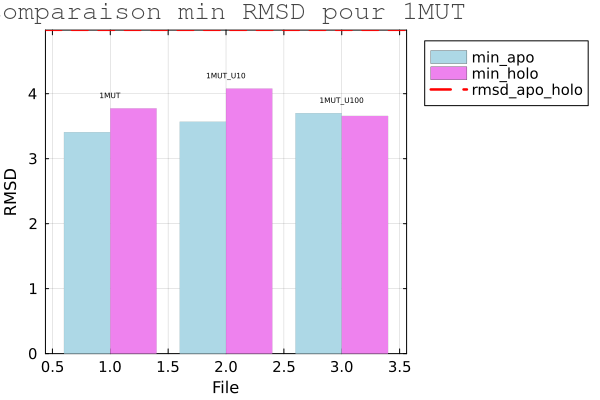

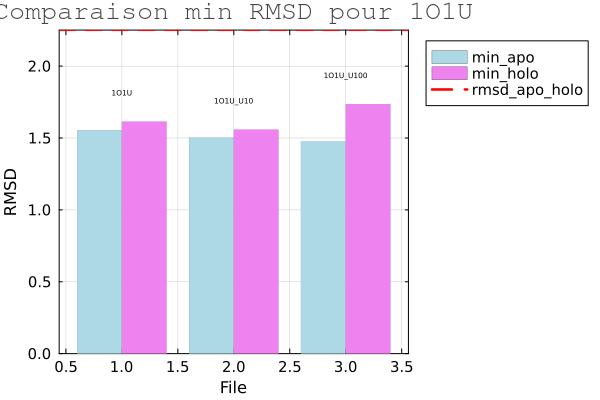

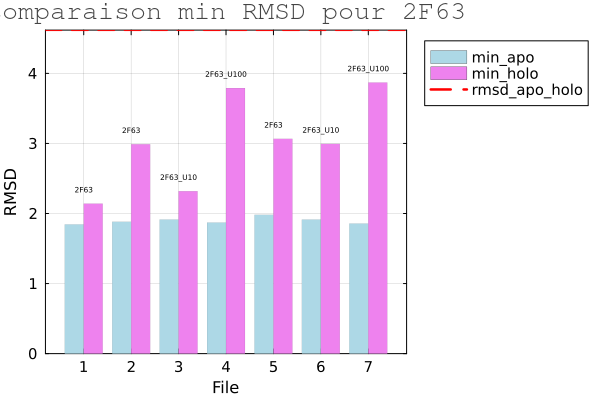

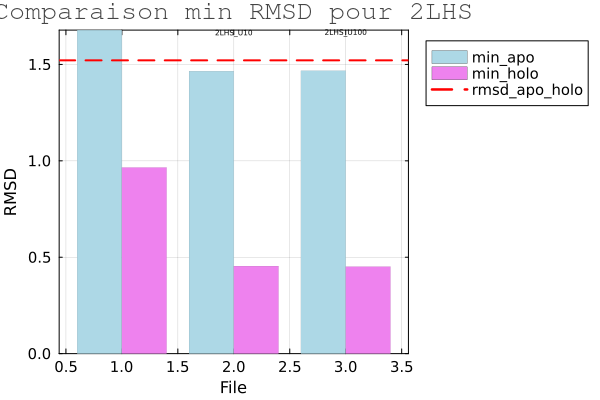

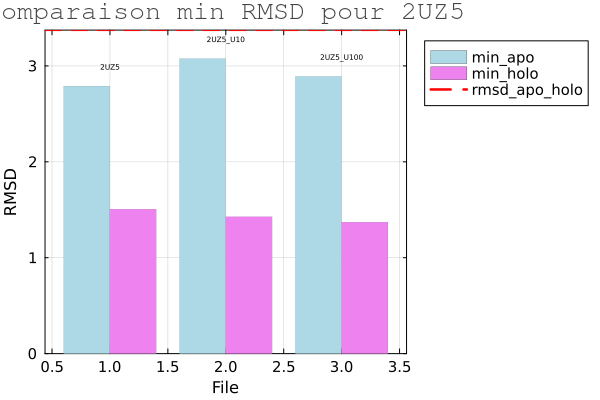

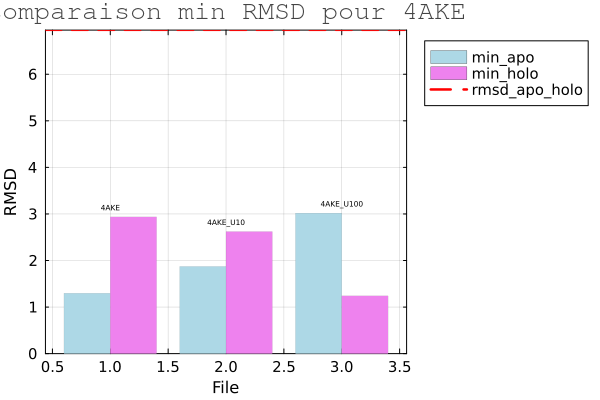

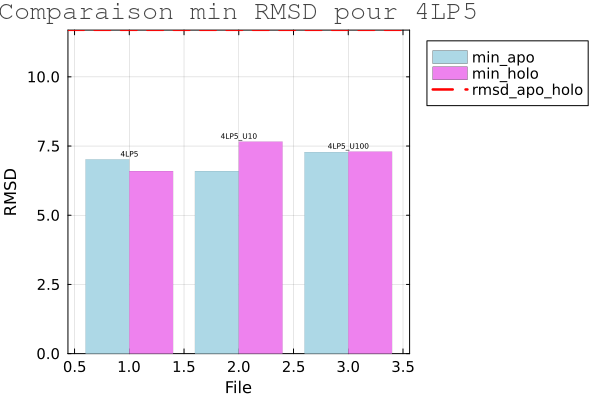

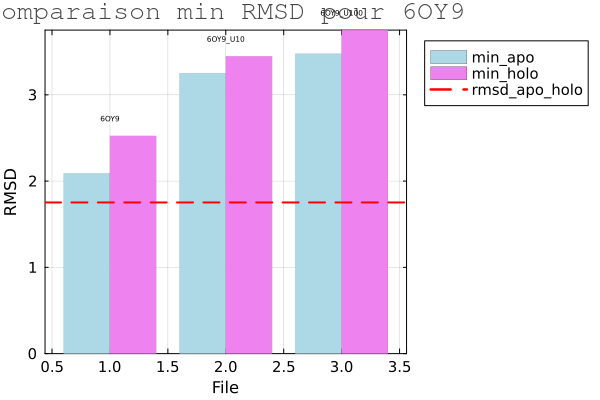

SubString{String15}["1AKZ", "1FMF", "1GQN", "1HW1", "1MUT", "1O1U", "2F63", "2LHS", "2UZ5", "4AKE", "4LP5", "6OY9"]


In [14]:
using DataFrames, StatsPlots, CSV, Colors

# Charger les données
df_path = "Compare_output_AF.csv"
df = DataFrame(CSV.File(df_path, comment="#", missingstring=["", "None"]))

# Trouver les pdb uniques (ex: 1AKZ, 1FMF, etc.)
pdb_names = unique([split(file, "_")[1] for file in df.File])
println(pdb_names)

# Couleurs
apo_color = :lightblue
holo_color = :violet
line_color = :red

# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.min_apo
    min_holo_vals = df_subset.min_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison min RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end


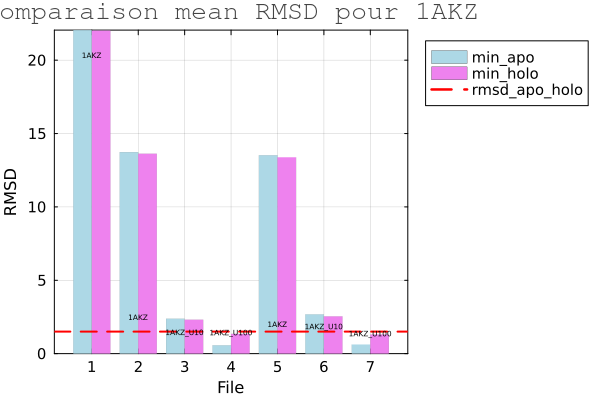

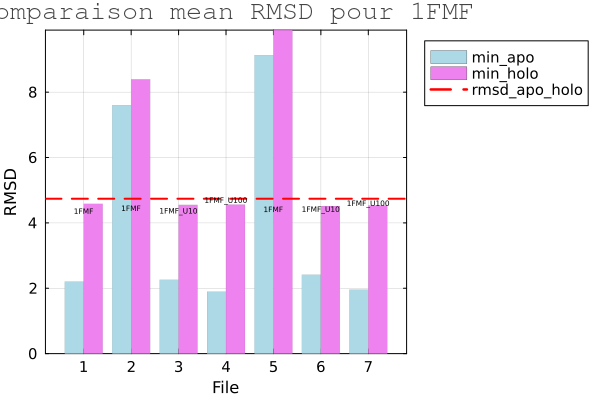

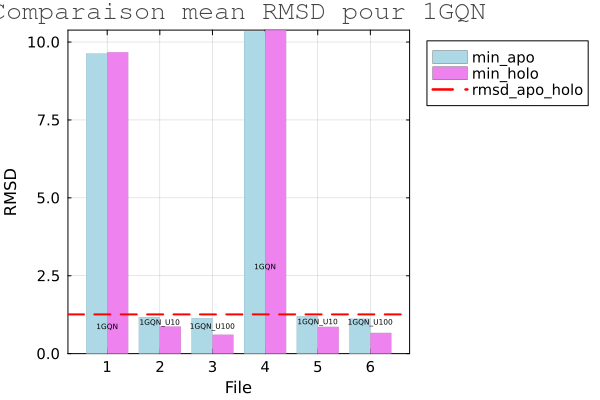

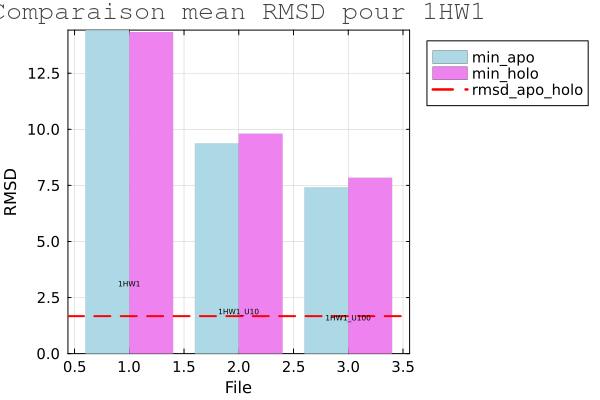

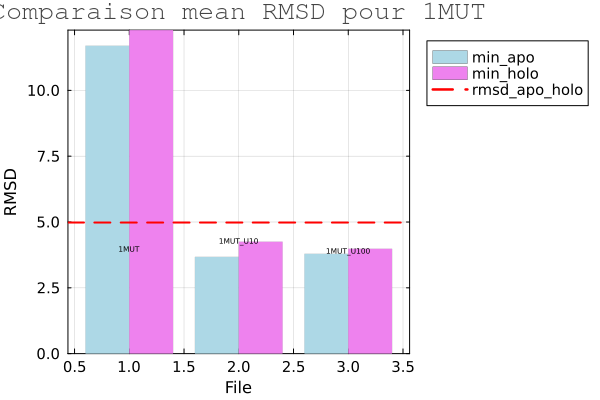

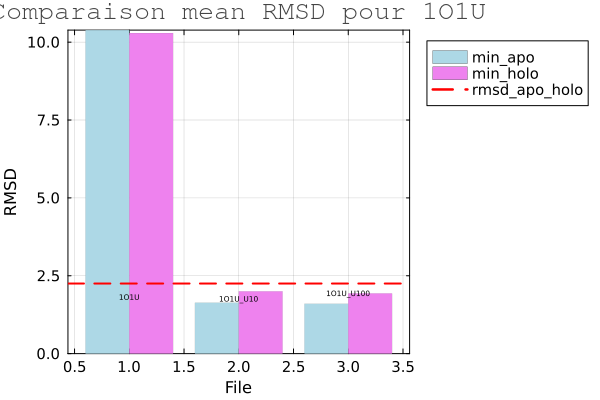

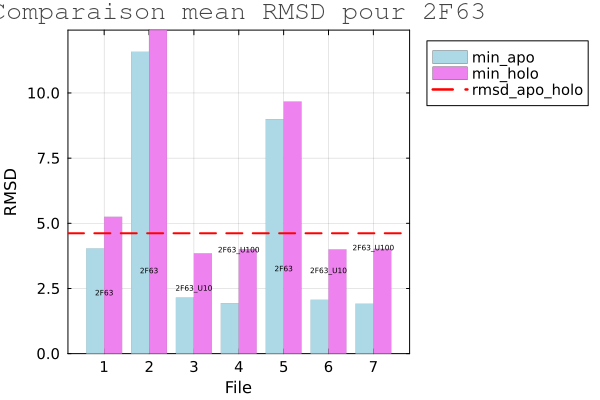

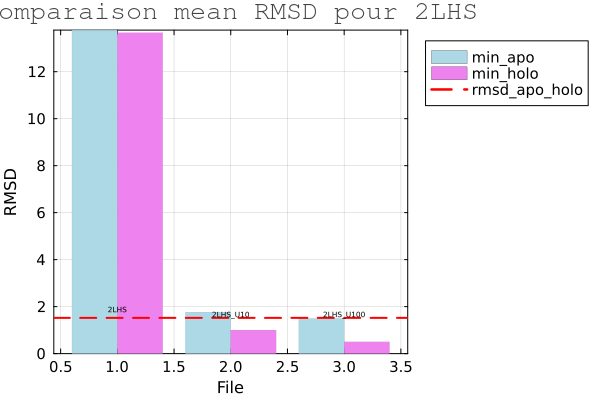

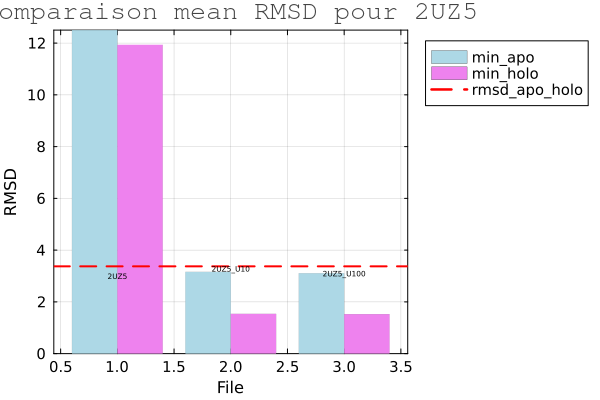

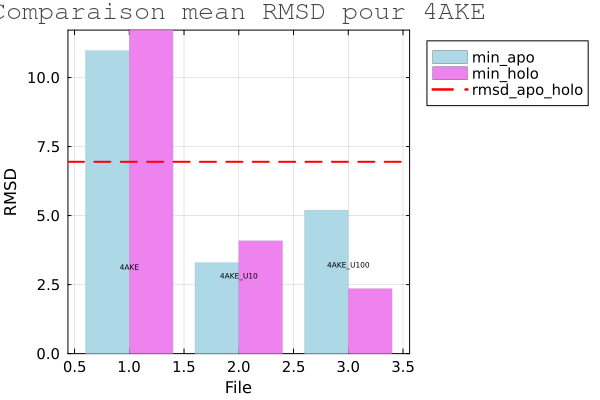

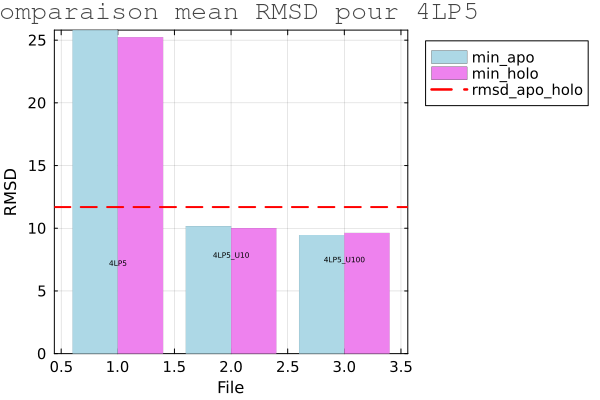

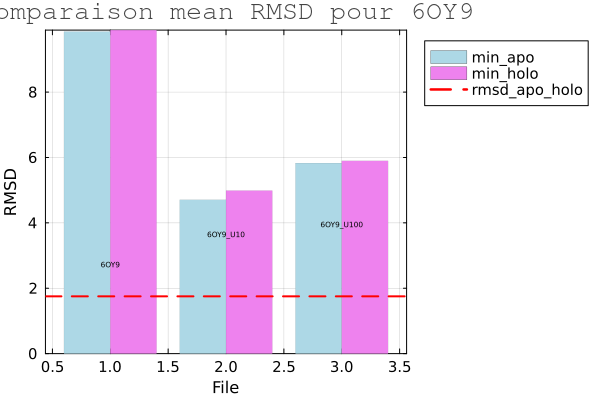

In [15]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.mean_apo
    min_holo_vals = df_subset.mean_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison mean RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end


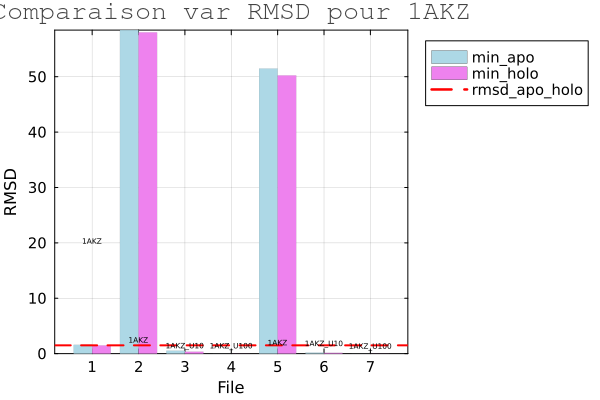

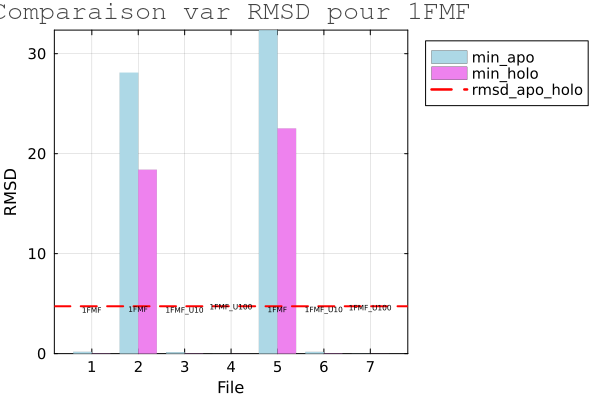

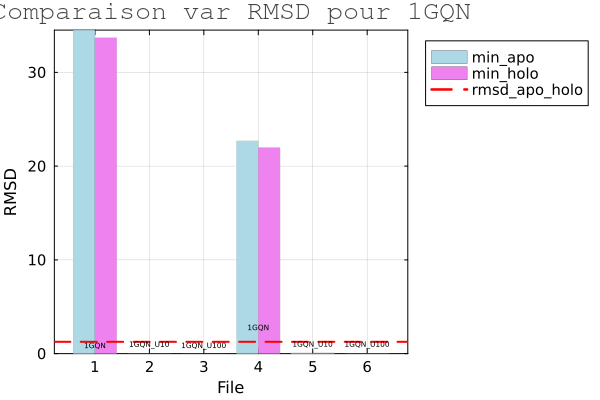

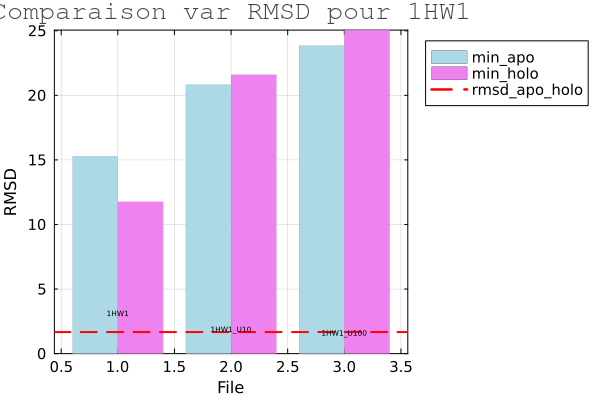

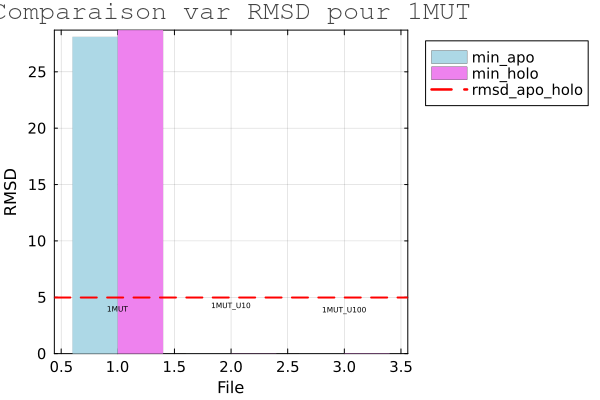

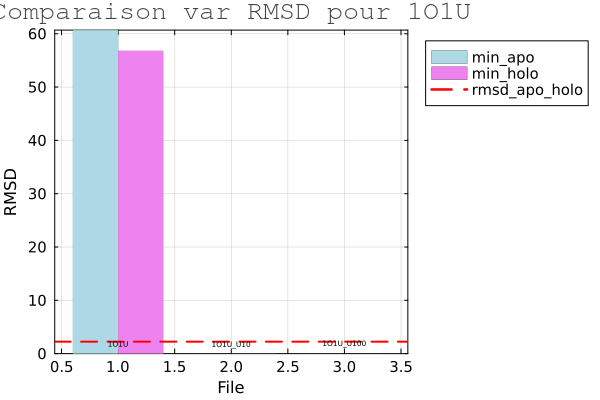

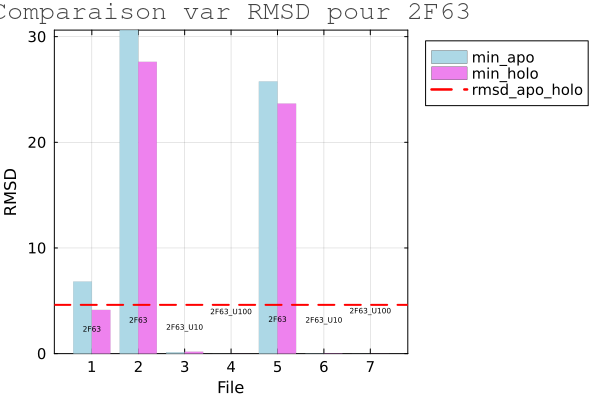

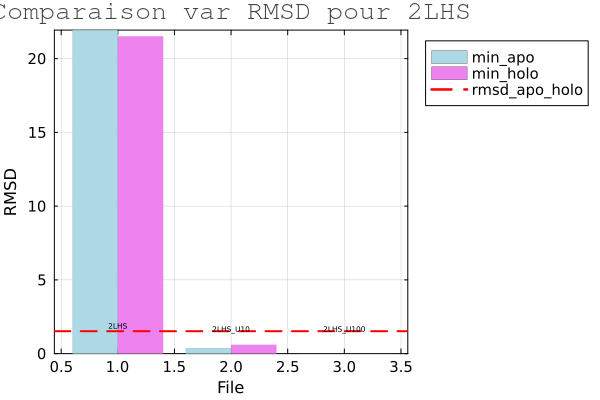

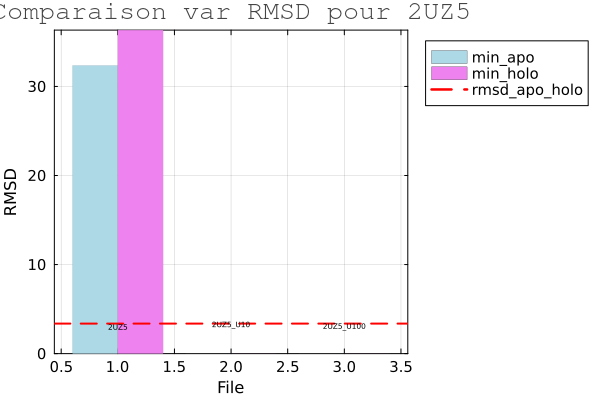

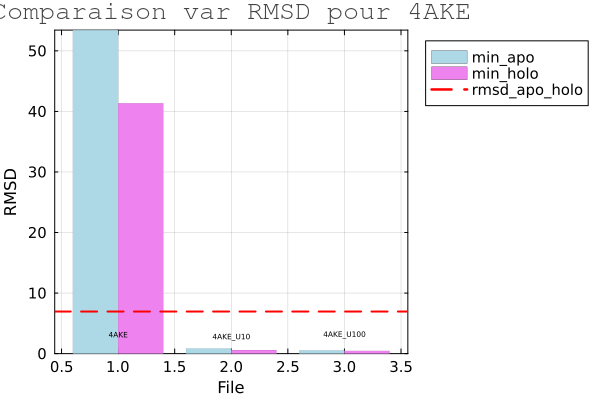

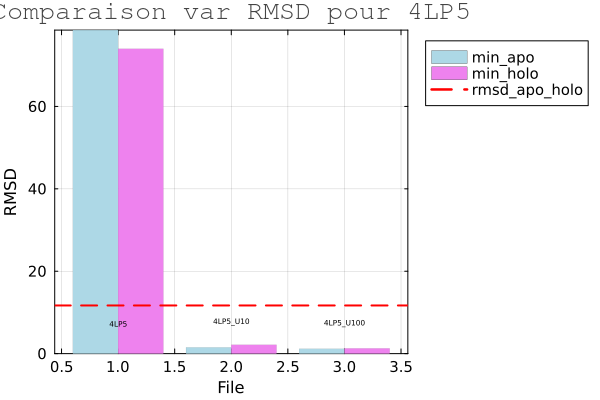

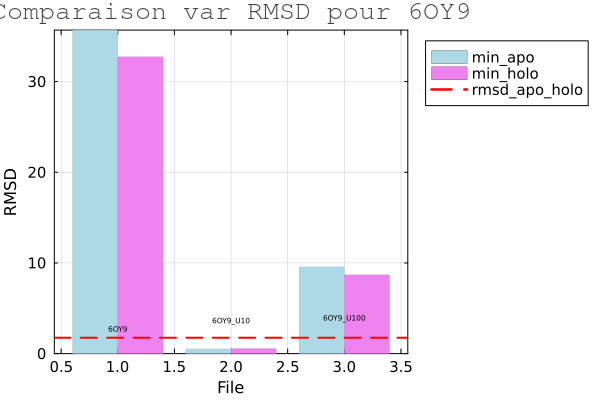

In [16]:
# Créer un graphique pour chaque PDB
for pdb in pdb_names
    # Sous-dataframe correspondant à ce PDB
    df_subset = filter(row -> startswith(row.File, pdb), df)
    # Création des données pour le barplot
    labels = String.(df_subset.File)
    min_apo_vals = df_subset.var_apo
    min_holo_vals = df_subset.var_holo
    rmsd_val = first(df_subset.rmsd_apo_holo)  # identique pour tous les row
    # Barplot groupé
    p = groupedbar(
        [min_apo_vals min_holo_vals],
        bar_position = :dodge,
        label = ["min_apo" "min_holo"],
        title = "Comparaison var RMSD pour $pdb",
        xlabel = "File",
        ylabel = "RMSD",
        lw = 0,
        c = [apo_color holo_color],
        legend = :outertopright,
        titlefont = font(14, "Arial"),
        tickfont = font(10),
        legendfontsize = 10,
        framestyle = :box
    )

    # Ligne horizontale rouge pour rmsd_apo_holo
    hline!(p, [rmsd_val], color = line_color, lw = 2, linestyle = :dash, label = "rmsd_apo_holo")

    # Annotation : Folders pour chaque File
    for (i, row) in enumerate(eachrow(df_subset))
        annotate!(p, (i, max(row.min_apo, row.min_holo) + 0.2, text(row.File, :black,5)))
    end

    # Affiche ou sauvegarde
    display(p)
    # savefig(p, "rmsd_plot_$pdb.png")  # optionnel
end
